<a href="https://colab.research.google.com/github/dositadi/beures_housing/blob/main/Beures_Housing_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
# file name pattern
pattern = "/content/drive/MyDrive/world_quant/phase2/buenos-aires-real-estate-*.csv"

In [4]:
from glob import glob
import pandas as pd
import numpy as np

In [5]:
# write a merged files function that merges all the files in the glob (this is for reusability sake)

def merged_files(pattern: str) -> pd.DataFrame:
  return pd.concat([pd.read_csv(path) for path in glob(pattern)],ignore_index=True)

In [6]:
# write a reusable function to filter and keep only Capital Federal apartments under $400K
def filter_data(dataframe: pd.DataFrame) -> pd.DataFrame:
  return (
      dataframe
      .loc[lambda df: df['place_with_parent_names']
           .str.contains('Capital Federal')]
      .loc[lambda df: df['property_type'] == "apartment"]
      .loc[lambda df: df['price_aprox_usd'] < 400_000]
  )

In [7]:
# write a reusable function to handle the outlier using the quantile based approach
def outlier_df(outlier_data: pd.DataFrame) -> pd.DataFrame:
  return (outlier_data.loc[lambda df: df['surface_covered_in_m2'].between(df['surface_covered_in_m2'].quantile(0.1), df['surface_covered_in_m2'].quantile(0.9))])

In [8]:
# write a reusable function for feature engineering
def modify_col(dataframe: pd.DataFrame) -> pd.DataFrame:
  return (
      dataframe.assign(
          lat = lambda df:
            df['lat-lon'].str.split(',',expand=True)[0].astype(np.float64),
          lon = lambda df:
            df['lat-lon'].str.split(',',expand=True)[1].astype(np.float64),
          neighbourhood = lambda df:
            df['place_with_parent_names'].str.split('|', expand=True)[3]
      )
  )

In [9]:
# Final master function to clean the entire dataset
def clean_files(pattern: str) -> pd.DataFrame:
  ''' Final master function to clean the entire dataset '''
  drop_cols = [
    "lat-lon", "place_with_parent_names",
    "floor", "expenses", "rooms", "price",
    "price_aprox_local_currency", "price_usd_per_m2",
    "price_per_m2", "operation", "property_type", "currency",
    "properati_url", "surface_total_in_m2"
  ]

  return (
      merged_files(pattern)
      .pipe(filter_data)
      .pipe(outlier_df)
      .pipe(modify_col)
      .drop(columns=drop_cols)
      .dropna()
  )

In [10]:
df = clean_files(pattern=pattern)

display(df.info())

df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 6247 entries, 4 to 43021
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   price_aprox_usd        6247 non-null   float64
 1   surface_covered_in_m2  6247 non-null   float64
 2   lat                    6247 non-null   float64
 3   lon                    6247 non-null   float64
 4   neighbourhood          6247 non-null   object 
dtypes: float64(4), object(1)
memory usage: 292.8+ KB


None

,price_aprox_usd,surface_covered_in_m2,lat,lon,neighbourhood
4,129000.0,70.0,-34.584651,-58.454693,Chacarita
9,87000.0,42.0,-34.638979,-58.500115,Villa Luro
29,118000.0,54.0,-34.615847,-58.459957,Caballito
40,57000.0,42.0,-34.625222,-58.382382,Constitución
41,90000.0,50.0,-34.610610,-58.412511,Once


# Splitting the dataset

In [11]:
target = 'price_aprox_usd'
features = [col for col in df.columns if col not in [target]]

X = df[features]
y = df[target]

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (6247, 4)
y shape: (6247,)


# Performing train test split

In [12]:
from sklearn.model_selection  import train_test_split

In [13]:
# y_test = expected price for prediction on test dataset
# y_train = expected price for prediction on train dataset
X_train, X_test, y_train, y_test = train_test_split(X,y,random_state=42,test_size=0.2)

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

Training set shape: (4997, 4)
Test set shape: (1250, 4)


## Ridge Regression Pipeline

Now we build our first regularized model. Instead of applying encoding and scaling manually, we will use a scikit-learn **Pipeline** that bundles all preprocessing and modeling steps into a single object.

> 📌 **`make_pipeline` vs. `Pipeline`**: Scikit-learn offers two syntaxes for creating pipelines. `make_pipeline(step1, step2, step3)` automatically assigns step names based on class names (e.g., `onehotencoder`, `standardscaler`, `ridge`). `Pipeline([("encode", step1), ("scale", step2), ("model", step3)])` lets you choose the step names explicitly. Either works; `make_pipeline` is more concise for quick experiments, while named `Pipeline` is clearer in production code where you need to access specific steps by name — which we will do in Section 6 when extracting coefficients.

## 2. The Need for Feature Scaling

Before we can apply regularization, we must address a mathematical prerequisite: **feature scaling**.

**StandardScaler** applies the transformation:

$$z = \frac{x - \mu}{\sigma}$$

where $\mu$ is the column mean and $\sigma$ is the standard deviation, both computed from the training data. After transformation, every feature has mean = 0 and standard deviation = 1.

In [14]:
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.9/107.9 kB 3.6 MB/s eta 0:00:00


In [15]:
from category_encoders import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import root_mean_squared_error

## Make ridge pipeline

In [16]:
model_ridge = make_pipeline(
    OneHotEncoder(use_cat_names=True),
    StandardScaler(),
    Ridge(alpha=1.0)
)

model_ridge

Pipeline(steps=[('onehotencoder', OneHotEncoder(use_cat_names=True)),
                ('standardscaler', StandardScaler()), ('ridge', Ridge())])

In [17]:
model_ridge.fit(X_train, y_train)

Pipeline(steps=[('onehotencoder',
                 OneHotEncoder(cols=['neighbourhood'], use_cat_names=True)),
                ('standardscaler', StandardScaler()), ('ridge', Ridge())])

In [18]:
# predict on training data
y_pred_ridge_train = model_ridge.predict(X_train)
rmse_ridge_train = root_mean_squared_error(y_train,y_pred_ridge_train)

print(f"Ridge training RMSE: {rmse_ridge_train:,.2f}")

# predict on test data
y_pred_ridge_test = model_ridge.predict(X_test)
rmse_ridge_test = root_mean_squared_error(y_test,y_pred_ridge_test)

print(f"Ridge test RMSE: {rmse_ridge_test:,.2f}")

Ridge training RMSE: 34,200.44
Ridge test RMSE: 33,087.85


## Make Lasso pipeline

In [19]:
model_lasso = make_pipeline(
    OneHotEncoder(use_cat_names=True),
    StandardScaler(),
    Lasso(alpha=100,max_iter=10_000)
)

model_lasso

Pipeline(steps=[('onehotencoder', OneHotEncoder(use_cat_names=True)),
                ('standardscaler', StandardScaler()),
                ('lasso', Lasso(alpha=100, max_iter=10000))])

In [20]:
model_lasso.fit(X_train, y_train)

Pipeline(steps=[('onehotencoder',
                 OneHotEncoder(cols=['neighbourhood'], use_cat_names=True)),
                ('standardscaler', StandardScaler()),
                ('lasso', Lasso(alpha=100, max_iter=10000))])

In [21]:
# predict on training set
y_pred_lasso_train = model_lasso.predict(X_train)
rmse_lasso_train = root_mean_squared_error(y_train, y_pred_lasso_train)

print(f"Lasso training RMSE: {rmse_lasso_train:,.2f}")

# predict on test data
y_pred_lasso_test = model_lasso.predict(X_test)
rmse_lasso_test = root_mean_squared_error(y_test,y_pred_lasso_test)

print(f"Lasso test RMSE: {rmse_lasso_test:,.2f}")

Lasso training RMSE: 34,224.83
Lasso test RMSE: 33,053.24


# Ridge: Exploring the Bias-Variance Tradeoff
The regularization strength $\alpha$ is a **hyperparameter** — a setting you choose before training, not one the model learns from data. Getting it right is critical.

### The bias-variance tradeoff

$\alpha$ controls a fundamental tradeoff between two types of error:

**Bias** is the error from using too simple a model. A model with very high bias systematically misses real patterns in the data — it is not flexible enough to fit the training set well, let alone generalize.

**Variance** is the error from using too complex a model. A high-variance model fits training data so closely that small changes in the training set would produce wildly different predictions — it has memorized noise instead of learning signal.

In [22]:
# Exploring ridge bias-variance using a range of alpha weight
alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1_000]
ridge_results = []

for a in alphas:
  # Initialize the model
  model_ridge = make_pipeline(
      OneHotEncoder(use_cat_names=True),
      StandardScaler(),
      Ridge(alpha=a)
  )
  # fit the model with training set
  model_ridge.fit(X_train, y_train)

  # predict with the model training set
  y_pred_ridge_train = model_ridge.predict(X_train)
  rmse_train = root_mean_squared_error(y_train,y_pred_ridge_train)

  # predict with the model test set
  y_pred_ridge_test = model_ridge.predict(X_test)
  rmse_test = root_mean_squared_error(y_test, y_pred_ridge_test)

  ridge_results.append({
    "alpha": a,
    "rmse_train": rmse_train,
    "rmse_test": rmse_test,
  })

df_ridge_results = pd.DataFrame(ridge_results)
df_ridge_results


,alpha,rmse_train,rmse_test
0,0.001,34200.432952,33088.372087
1,0.010,34200.432953,33088.367313
2,0.100,34200.432974,33088.319603
3,1.000,34200.435086,33087.845694
4,10.000,34200.639955,33083.415038
5,100.000,34216.977947,33062.388861
6,1000.000,35069.439956,33744.376028


Create a line plot showing the bias-variance tradeoff for Ridge. Plot training RMSE and test RMSE on the y-axis, with alpha on the x-axis (log scale).

In [23]:
import matplotlib.pyplot as plt


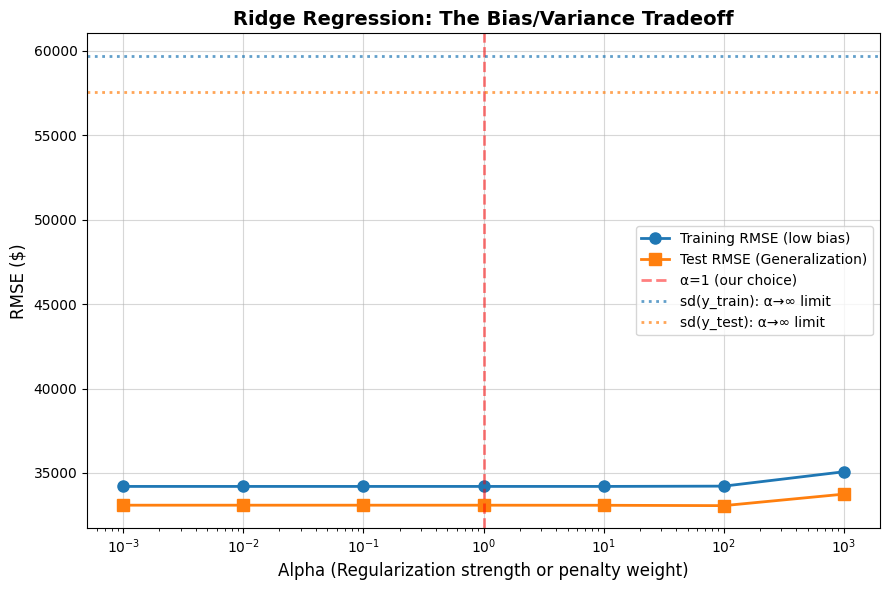

In [24]:
fig, ax = plt.subplots(figsize=(9,6))

# Create a plot for the training set
ax.plot(df_ridge_results['alpha'], df_ridge_results['rmse_train'],marker='o', linewidth=2, label="Training RMSE (low bias)", markersize=8)

# Create a plot for the test set
ax.plot(df_ridge_results['alpha'],df_ridge_results['rmse_test'], marker='s', linewidth=2, label="Test RMSE (Generalization)", markersize=8)

# create the axv line for the alpha on the x axis to mark the alpha threshold
ax.axvline(x=1, linewidth=2, linestyle="--", color="r", alpha=0.5, label="α=1 (our choice)")

# Where each curve must converge as alpha -> infinity (model predicts the training mean)
# axhline for train set as α→∞ limit
ax.axhline(y=y_train.std(), linewidth=2, linestyle=":", color="C0",alpha=0.7,label="sd(y_train): α→∞ limit")
# axhline for test set as α→∞ limit
ax.axhline(y=y_test.std(), linewidth=2, linestyle=":", color="C1", alpha=0.7, label="sd(y_test): α→∞ limit")

ax.set_xlabel("Alpha (Regularization strength or penalty weight)", fontsize=12)
ax.set_ylabel("RMSE ($)", fontsize=12)
# change the scale on x-axis from linear to a lograthmic scale
ax.set_xscale("log")
ax.set_title("Ridge Regression: The Bias/Variance Tradeoff", fontsize=14, fontweight="bold")

ax.grid(True, alpha=0.5)
ax.legend()

fig.tight_layout()
fig.show()

# Lasso: Feature Selection with Regularization


In [25]:
alphas = [0.1, 1,10,100,1_000]
lasso_results = []

for a in alphas:
  # initialize the model
  model_lasso = make_pipeline(
      OneHotEncoder(use_cat_names=True),
      StandardScaler(),
      Lasso(alpha=a,max_iter=10_000)
  )

  # fit the model with the datasets
  model_lasso.fit(X_train, y_train)

  # predict from train set
  y_pred_train = model_lasso.predict(X_train)
  rmse_train = root_mean_squared_error(y_true=y_train, y_pred=y_pred_train)

  # predict from test set
  y_pred_test = model_lasso.predict(X_test)
  rmse_test = root_mean_squared_error(y_true=y_test, y_pred=y_pred_test)

  # Get the sum of the remaining feature in the dataset
  non_zero_features = (model_lasso.named_steps['lasso'].coef_ != 0).sum()

  lasso_results.append({
      "alpha":a,
      "rmse_train":rmse_train,
      "rmse_test":rmse_test,
      "non_zero_features":non_zero_features
  })

df_lasso_results = pd.DataFrame(lasso_results)

df_lasso_results

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.670e+11, tolerance: 1.781e+09
  model = cd_fast.enet_coordinate_descent(


,alpha,rmse_train,rmse_test,non_zero_features
0,0.1,34200.432980,33088.297202,59
1,1.0,34200.435537,33087.686878,58
2,10.0,34200.691205,33081.797922,58
3,100.0,34224.825010,33053.242280,56
4,1000.0,34772.392675,33646.034886,27


Compare Ridge and Lasso alpha selection visually.

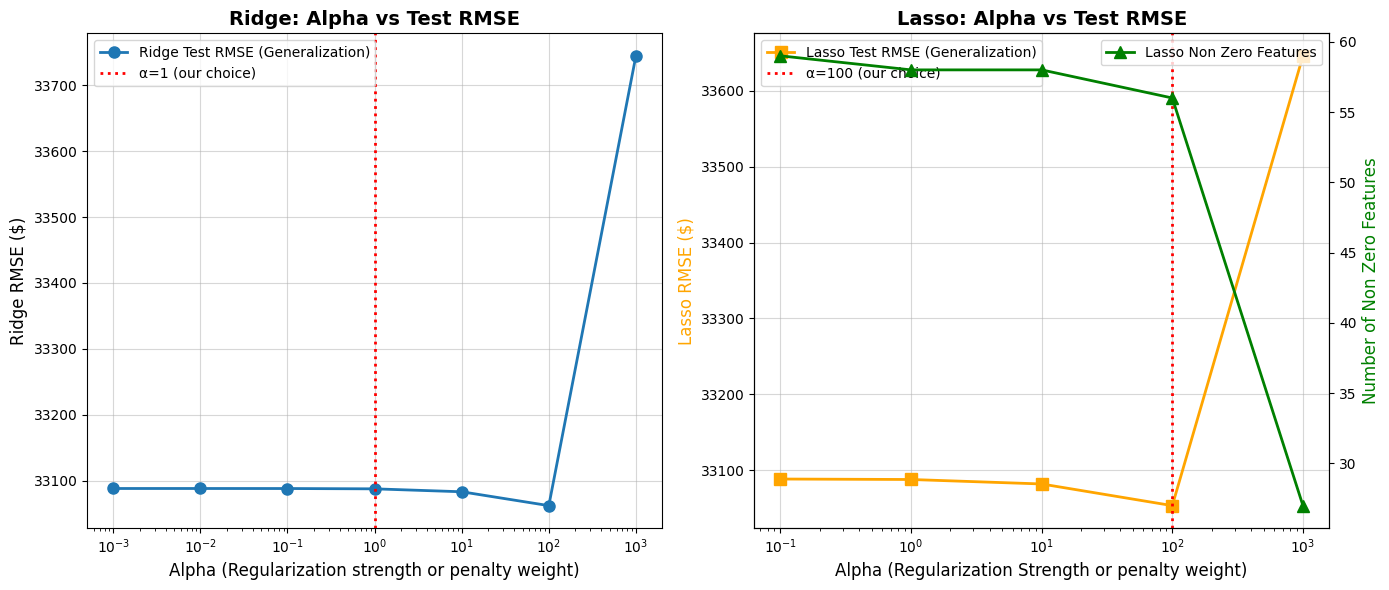

In [26]:
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(14,6))

# RIDGE COMPARISON PLOT
ax1.plot(df_ridge_results['alpha'], df_ridge_results['rmse_test'], marker="o", markersize=8, linewidth=2, label="Ridge Test RMSE (Generalization)")

# Plot the axvline to display the model alpha threshold
ax1.axvline(x=1, linestyle=":", linewidth=2, color="r", label="α=1 (our choice)")
ax1.set_xscale("log")
ax1.set_xlabel("Alpha (Regularization strength or penalty weight)", fontsize=12)
ax1.set_ylabel("Ridge RMSE ($)", fontsize=12)
ax1.set_title("Ridge: Alpha vs Test RMSE", fontweight="bold", fontsize=14)

ax1.grid(visible=True,alpha=0.5)
ax1.legend()

# LASSO COMPARISON PLOT WITH FEATURE COUNT
# plot alpha vs rmse_test
ax2.plot(df_lasso_results['alpha'], df_lasso_results['rmse_test'], marker="s", markersize=8, linewidth=2, label="Lasso Test RMSE (Generalization)", color="orange")
# plot the axvline to display the alpha threshold at 100
ax2.axvline(x=100,linestyle=":", color="r", linewidth=2, label="α=100 (our choice)")
# set the alpha scale to log
ax2.set_xscale("log")
ax2.grid(visible=True, alpha=0.5)
ax2.legend(loc="upper left")
ax2.set_ylabel("Lasso RMSE ($)", fontsize=12, color="orange")
ax2.set_xlabel("Alpha (Regularization Strength or penalty weight)", fontsize=12)
ax2.set_title("Lasso: Alpha vs Test RMSE", fontweight="bold", fontsize=14)

# plot alpha vs non_zero_features on a  twin plot
ax2_twin = ax2.twinx()
ax2_twin.plot(df_lasso_results['alpha'], df_lasso_results['non_zero_features'], marker='^', markersize=8, linewidth=2, label="Lasso Non Zero Features", color="green")
ax2_twin.set_ylabel("Number of Non Zero Features", color="green", fontsize=12)
ax2_twin.legend(loc="upper right")

fig.tight_layout()
fig.show()


### 5.3 Automated Alpha Selection: RidgeCV and LassoCV

Manually testing a grid of $\alpha$ values and eyeballing the U-curve is informative but not rigorous. **Cross-validation** provides a principled, statistically reliable method for selecting $\alpha$.

`RidgeCV` and `LassoCV` implement this procedure automatically — you simply pass a list of candidate alphas and the model selects the best one internally. The selected alpha is stored in `model.named_steps["ridgecv"].alpha_` after fitting.

> **RidgeCV and LassoCV — Key Properties**
>
> - `RidgeCV(alphas=[...])` automatically selects the best $\alpha$ from the provided list using cross-validation. The chosen alpha is stored in `model.alpha_` after fitting.
> - `LassoCV(cv=5)` similarly selects the optimal alpha and stores it in `model.alpha_`. The `cv` parameter specifies the number of folds.
> - Both integrate naturally into Pipelines: `make_pipeline(OHE, Scaler, RidgeCV(alphas=[...]))` works exactly like the non-CV versions.
>
> **Why not always use CV?** Cross-validation is computationally more expensive — it fits the model $k \times |\text{alphas}|$ times instead of once. For small datasets and fast models (like Ridge and Lasso), this cost is negligible. For large datasets or slow models, you might accept a slightly suboptimal $\alpha$ to save computation.

In [27]:
from sklearn.linear_model import LassoCV, RidgeCV

In [28]:
# Training with a LassoCV learn estimator
model_lasso_cv = make_pipeline(
    OneHotEncoder(use_cat_names=True),
    StandardScaler(),
    LassoCV(alphas=[0.1,1,10,100,1_000],cv=5 ,max_iter=10_000)
)

# fit the model with train set
model_lasso_cv.fit(X_train,y_train)
rmse_lassocv_train = root_mean_squared_error(y_train,model_lasso_cv.predict(X_train))

# fit model with test set
rmse_lassocv_test = root_mean_squared_error(y_test, model_lasso_cv.predict(X_test))

selected_alpha = model_lasso_cv.named_steps['lassocv'].alpha_
non_zero_features = (model_lasso_cv.named_steps['lassocv'].coef_ != 0).sum()
total_features = len(model_lasso_cv.named_steps['lassocv'].coef_)

print(f"LassoCV Train RMSE: ${rmse_lassocv_train:,.2f}")
print(f"LassoCV Test RMSE: ${rmse_lassocv_test:,.2f}")
print(f"Total features: {total_features}")
print(f"Non zero features: {non_zero_features:,.2f}")
print(f"Selected Alpha: {selected_alpha}")

LassoCV Train RMSE: $34,200.69
LassoCV Test RMSE: $33,081.80
Total features: 59
Non zero features: 58.00
Selected Alpha: 10.0


In [29]:
# Training with a RidgeCV learn estimator
model_ridge_cv = make_pipeline(
    OneHotEncoder(use_cat_names=True),
    StandardScaler(),
    RidgeCV(alphas=[0.001,0.01,0.1,1,10,100,1_000,10_000,100_000,1_000_000],cv=5)
)

# fit the model with train set
model_ridge_cv.fit(X_train, y_train)
rmse_ridgecv_train = root_mean_squared_error(y_train, model_ridge_cv.predict(X_train))

# fit the model with test set
rmse_ridgecv_test = root_mean_squared_error(y_test,model_ridge_cv.predict(X_test))

selected_alpha = model_ridge_cv.named_steps['ridgecv'].alpha_
total_features = len(model_ridge_cv.named_steps['ridgecv'].coef_)

print(f"RidgeCV Train RMSE: {rmse_ridgecv_train:,.2f}")
print(f"RidgeCV Test RMSE: {rmse_ridgecv_test:,.2f}")
print(f"Selected alpha: {selected_alpha}")
print(f"Total features: {total_features}")


RidgeCV Train RMSE: 34,216.98
RidgeCV Test RMSE: 33,062.39
Selected alpha: 100.0
Total features: 59


## 6. Visualizing and Interpreting Coefficients

The true power of Lasso's feature selection becomes visible when we examine the coefficients directly. Let's extract them and see which features the model kept and which it zeroed out.

In [30]:
coefficients = model_lasso_cv.named_steps['lassocv'].coef_

feature_names = model_lasso.named_steps['onehotencoder'].get_feature_names_out()

coeff_series = pd.Series(data=coefficients, index=feature_names)

coeff_series.head()
print(f"\nTotal Features: {coeff_series.shape[0]}")
print(f"Non Zero Features: {(coeff_series != 0).sum()}")


Total Features: 59
Non Zero Features: 58


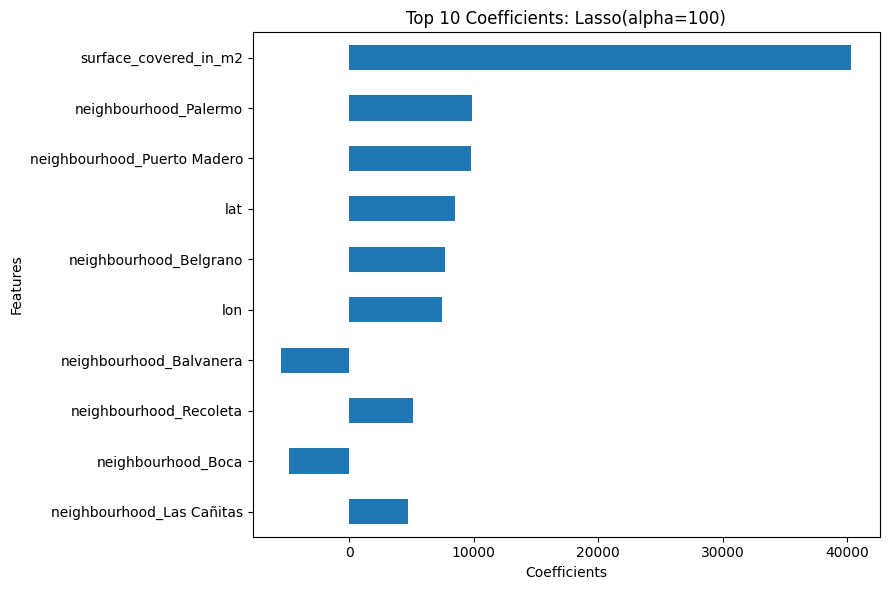

In [31]:
# Visualizing the top coefficients.
fig, ax = plt.subplots(figsize=(9,6))
coeff_series.sort_values(key=abs).tail(10).plot(kind="barh",ax=ax)
ax.set_xlabel("Coefficients")
ax.set_ylabel("Features")
ax.set_title("Top 10 Coefficients: Lasso(alpha=100)")
fig.tight_layout()
fig.show()

In [32]:
# Lasso features analysis
zero_features_count = (coeff_series == 0).sum()
print(f"Lasso removed {zero_features_count} features out of {len(coeff_series)} total features")
print(f"The percentage of the removed features is {zero_features_count/len(coeff_series) * 100:.2f}%")

Lasso removed 1 features out of 59 total features
The percentage of the removed features is 1.69%


### Interpreting Lasso Coefficients

Lasso coefficients require more careful interpretation than OLS coefficients. Two important caveats apply:

**Caveat 1: Coefficients are on the standardized scale**

After `StandardScaler`, every feature has mean = 0 and standard deviation = 1. A coefficient of +50,000 on `neighborhood_Palermo` does not mean "Palermo adds $50,000 to the price in raw square-meter terms." It means Palermo adds $50,000 per *standard deviation* of the scaled feature — which, for a binary indicator column, essentially means $50,000 per unit of being in Palermo.

**Caveat 2: Coefficients reflect the post-selection model**

Lasso has already eliminated ~60% of features. The surviving coefficients are not just estimates of those features' effects in isolation — they are estimates *after the other eliminated features have been removed*. If Lasso zeroed out `neighborhood_Recoleta` but kept `neighborhood_Palermo`, the Palermo coefficient absorbs some of the effect that Recoleta might have partially shared.

> **Practical interpretation guideline:**
>
> For business communication, the cleanest interpretation is relative: "Apartments in neighborhood X are predicted to sell for approximately $Y more (or less) than apartments in the baseline neighborhood, holding size and location fixed." The exact dollar amount is an approximation, but the direction and rough magnitude are reliable.

In [33]:
# Show top 5 positive and negative coefficients
print("="*60)
print("5 Top Positive Coefficients")
print("="*60)
positive_coeff = coeff_series.nlargest(5)
for feature ,coeff in positive_coeff.items():
  print(f"{feature:40} {coeff:>10.2f}")

print("\n"+"="*60)
print("5 Top Negative Coefficients")
print("="*60)
negative_coeff = coeff_series.nsmallest(5)
for feature, coeff in negative_coeff.items():
  print(f"{feature:40} {coeff:>10.2f}")

print("\n" + "=" * 60)
print("INTERPRETATION GUIDE")
print("=" * 60)
print("Remember: These coefficients are on STANDARDIZED features.")
print("A feature's importance depends on both its coefficient AND")
print("which other features Lasso eliminated. This is the 'feature")
print("selection' effect of Lasso in action.")

5 Top Positive Coefficients
surface_covered_in_m2                      40365.65
neighbourhood_Palermo                       9874.97
neighbourhood_Puerto Madero                 9744.97
lat                                         8470.99
neighbourhood_Belgrano                      7654.51

5 Top Negative Coefficients
neighbourhood_Balvanera                    -5480.94
neighbourhood_Boca                         -4891.64
neighbourhood_Once                         -4563.78
neighbourhood_Congreso                     -3421.55
neighbourhood_Constitución                 -2813.75

INTERPRETATION GUIDE
Remember: These coefficients are on STANDARDIZED features.
A feature's importance depends on both its coefficient AND
which other features Lasso eliminated. This is the 'feature
selection' effect of Lasso in action.


### 6.5 Residual Analysis: Univariate vs. Multivariate

Adding neighborhood, latitude, and longitude to the model should capture more of the systematic price variation that size alone could not explain. Let's verify this by comparing residual patterns.

**Hypothesis:** The multivariate residuals should be more randomly scattered than the univariate residuals from Lesson 2, because the model now captures neighborhood-level price effects that were previously "missing" and showing up as systematic patterns.

**Reading the residual plot for a multivariate model:**

With a single feature, we could plot residuals against that feature and directly see the pattern. With multiple features (surface area + lat + lon + 50+ neighborhood indicators), we plot residuals against the **predicted values** instead — the only single axis that summarizes all feature contributions.

The same interpretive rules apply:
- **Random scatter around zero:** All systematic variation is captured; remaining errors are unpredictable noise.
- **Funnel shape (heteroscedasticity):** Error variance increases with predicted price — a common pattern in financial data that linear models struggle to fully resolve.
- **Systematic curve:** The relationship is non-linear in ways the model's current features cannot capture.

Mean of Residuals: $-1,552.86 (should be close to zero)
Standard Deviation of Residuals: $33,623.63
Min Residual: $-132,392.24
Max Residual: $168,426.19


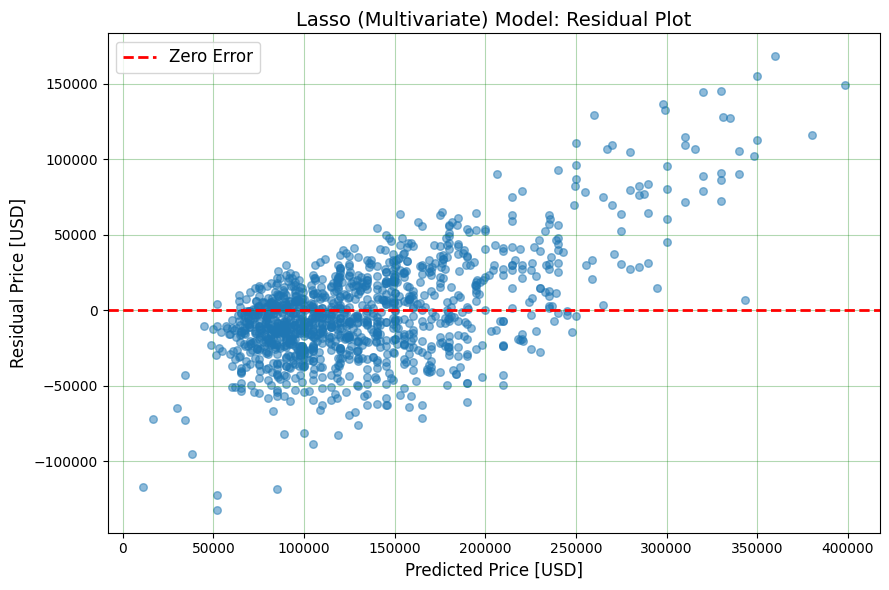

In [34]:
# getting the residual of lasso prediction
y_pred_test_lasso = model_lasso.predict(X_test)
residual_lasso = y_test - y_pred_test_lasso

fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(y_test, residual_lasso, alpha=0.5,s=30)
ax.axhline(y=0,linewidth=2,color='r',linestyle='--',label="Zero Error")

ax.set_xlabel("Predicted Price [USD]",fontsize=12)
ax.set_ylabel("Residual Price [USD]", fontsize=12)
ax.set_title("Lasso (Multivariate) Model: Residual Plot",fontsize=14)
ax.legend(fontsize=12)
ax.grid(visible=True,alpha=0.3, color='g')

fig.tight_layout()
fig.show()

print(f"Mean of Residuals: ${residual_lasso.mean():,.2f} (should be close to zero)")
print(f"Standard Deviation of Residuals: ${residual_lasso.std():,.2f}")
print(f"Min Residual: ${residual_lasso.min():,.2f}")
print(f"Max Residual: ${residual_lasso.max():,.2f}")

In [35]:
ridge_metrics = {
    "Model": "Ridge (α=1.0)",
    "RMSE_train": rmse_ridge_train,
    "RMSE_test": rmse_ridge_test,
    "Non-zero_features": "All"
}

lasso_metrics = {
    "Model": "Lasso (α=100)",
    "RMSE_train": root_mean_squared_error(y_train, model_lasso.predict(X_train)),
    "RMSE_test": rmse_lasso_test,
    "Non-zero_features": (coefficients != 0).sum()
}

df_comparison = pd.DataFrame([ridge_metrics, lasso_metrics])
print(df_comparison)

           Model    RMSE_train     RMSE_test Non-zero_features
0  Ridge (α=1.0)  34200.435086  33087.845694               All
1  Lasso (α=100)  34772.392675  33053.242280                58
